In [1]:

import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# la racine du projet 
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(ROOT_DIR)

from model.mctnet import MCTNet

print(f" Modèle importé depuis: {os.path.join(ROOT_DIR, 'model', 'mctnet.py')}")

 Modèle importé depuis: c:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\model\mctnet.py


In [2]:
data_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned'

# Covariables
cov = pd.read_csv(f'{data_path}/covariates.csv')

# Sentinel-2
X_s2 = np.load(f'{data_path}/X_sentinel2.npy')
y = np.load(f'{data_path}/y_labels.npy')

print(f"X_s2 shape: {X_s2.shape}")
print(f"y shape: {y.shape}")

X_s2 shape: (10487, 36, 13)
y shape: (10487,)


In [3]:


# Recharger les covariables depuis le fichier original
data_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned'
covariates = pd.read_csv(f'{data_path}/covariates.csv')

print("=" * 60)
print("DONNÉES RECHARGÉES")
print("=" * 60)
print(f"Shape: {covariates.shape}")
print(f"Colonnes: {covariates.columns.tolist()}")

DONNÉES RECHARGÉES
Shape: (10487, 12)
Colonnes: ['system:index', 'climate_dewpoint_mean', 'climate_precip_total', 'climate_temp_mean', 'file', 'label', 'soil_oc', 'soil_ph', 'soil_texture', 'topo_elevation', 'topo_landforms', '.geo']


In [4]:
# # CELLULE 3 : CORRECTION DES DONNEES DE SOL 
# print("\n" + "=" * 60)
# print("CORRECTION DES DONNEES DE SOL")
# print("=" * 60)

# # 1. Correction du pH (division par 10)
# cov['soil_ph'] = cov['soil_ph'] / 10.0
# print("pH corrige (division par 10)")

# # 2. Gestion des valeurs manquantes pour les colonnes numeriques
# for col in ['soil_ph', 'soil_oc']:
#     if cov[col].isna().sum() > 0:
#         median_val = cov[col].median()
#         cov[col].fillna(median_val, inplace=True)
#         print(f"{col}: {cov[col].isna().sum()} valeurs manquantes remplacees par mediane")

# # 3. Gestion des valeurs manquantes pour soil_texture (remplacer par la mode)
# print(f"soil_texture - valeurs manquantes avant traitement: {cov['soil_texture'].isna().sum()}")
# mode_value = cov['soil_texture'].mode()[0]
# cov['soil_texture'] = cov['soil_texture'].fillna(mode_value)
# print(f"soil_texture: valeurs manquantes remplacees par la mode: {mode_value}")
# print(f"soil_texture - valeurs manquantes apres traitement: {cov['soil_texture'].isna().sum()}")

# # 4. Verifier qu'il n'y a plus de NaN
# if cov['soil_texture'].isna().sum() > 0:
#     print("ERREUR: Il reste des NaN dans soil_texture")
#     # Remplacer les NaN restants par 0
#     cov['soil_texture'] = cov['soil_texture'].fillna(0)
#     print("NaN restants remplaces par 0")

# # 5. One-hot encoding pour soil_texture
# encoder = OneHotEncoder(sparse_output=False, dtype=np.float32, handle_unknown='ignore')
# soil_encoded = encoder.fit_transform(cov[['soil_texture']])

# # 6. Ajouter les colonnes one-hot
# for i, cat in enumerate(encoder.categories_[0]):
#     # Convertir en entier seulement si la valeur n'est pas NaN
#     if pd.notna(cat):
#         col_name = f'soil_texture_{int(cat)}'
#     else:
#         col_name = f'soil_texture_nan'
#     cov[col_name] = soil_encoded[:, i]
#     print(f"  Ajoutee: {col_name}")

# # 7. Supprimer l'ancienne colonne
# cov = cov.drop('soil_texture', axis=1)
# print("soil_texture encode en one-hot avec succes")

In [5]:
climate_cols = ['climate_precip_total', 'climate_temp_mean', 'climate_dewpoint_mean']
soil_continuous_cols = ['soil_ph', 'soil_oc']
soil_onehot_cols = [c for c in cov.columns if c.startswith('soil_texture_')]
topo_cols = ['topo_elevation', 'topo_landforms']

X_climate = cov[climate_cols].values
X_soil = np.hstack([cov[soil_continuous_cols].values, cov[soil_onehot_cols].values])
X_topo = cov[topo_cols].values
X_all_cov = np.hstack([X_climate, X_soil, X_topo])

print(f"Climat: {X_climate.shape}")
print(f"Sol: {X_soil.shape}")
print(f"Topo: {X_topo.shape}")
print(f"Total: {X_all_cov.shape}")

Climat: (10487, 3)
Sol: (10487, 2)
Topo: (10487, 2)
Total: (10487, 7)


# normalisation

In [6]:
scaler_climate = StandardScaler()
scaler_soil = StandardScaler()
scaler_topo = StandardScaler()
scaler_all = StandardScaler()

X_climate_norm = scaler_climate.fit_transform(X_climate)
X_soil_norm = scaler_soil.fit_transform(X_soil)
X_topo_norm = scaler_topo.fit_transform(X_topo)
X_all_cov_norm = scaler_all.fit_transform(X_all_cov)

print("Normalisation terminee")


Normalisation terminee


# Cellule 3 : Normalisation des données Sentinel-2

In [7]:
X_s2_norm = np.zeros_like(X_s2)
for t in range(X_s2.shape[1]):
    for c in range(X_s2.shape[2]):
        mean = X_s2[:, t, c].mean()
        std = X_s2[:, t, c].std()
        if std > 0:
            X_s2_norm[:, t, c] = (X_s2[:, t, c] - mean) / std
        else:
            X_s2_norm[:, t, c] = X_s2[:, t, c]

print(f"Sentinel-2 normalise: {X_s2_norm.shape}")

Sentinel-2 normalise: (10487, 36, 13)


# 7 : ENCODAGE DES LABELS

In [8]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
n_classes = len(label_encoder.classes_)
print(f"Classes: {n_classes}")

Classes: 5


In [9]:
# CELLULE 8.6 : REMPLACER LES NAN DANS X_SOIL_NORM

print("=" * 60)
print("CORRECTION - REMPLACEMENT DES NAN DANS X_SOIL_NORM")
print("=" * 60)

# Verifier les NaN par colonne
print(f"NaN avant correction: {np.isnan(X_soil_norm).sum()}")

# Remplacer les NaN par la moyenne de chaque colonne
for col in range(X_soil_norm.shape[1]):
    col_mean = np.nanmean(X_soil_norm[:, col])
    if np.isnan(col_mean):
        col_mean = 0
    X_soil_norm[np.isnan(X_soil_norm[:, col]), col] = col_mean

# Verifier apres correction
print(f"NaN apres correction: {np.isnan(X_soil_norm).sum()}")

# Faire de meme pour X_all_cov_norm
print(f"\nNaN dans X_all_cov_norm avant correction: {np.isnan(X_all_cov_norm).sum()}")
for col in range(X_all_cov_norm.shape[1]):
    col_mean = np.nanmean(X_all_cov_norm[:, col])
    if np.isnan(col_mean):
        col_mean = 0
    X_all_cov_norm[np.isnan(X_all_cov_norm[:, col]), col] = col_mean
print(f"NaN dans X_all_cov_norm apres correction: {np.isnan(X_all_cov_norm).sum()}")

print("\n Correction terminee. Les NaN ont ete remplaces par la moyenne des colonnes.")

CORRECTION - REMPLACEMENT DES NAN DANS X_SOIL_NORM
NaN avant correction: 24
NaN apres correction: 0

NaN dans X_all_cov_norm avant correction: 24
NaN dans X_all_cov_norm apres correction: 0

 Correction terminee. Les NaN ont ete remplaces par la moyenne des colonnes.


# Cellule 6 : training 

In [10]:
# CELLULE 8 : Fonction d'entraînement et évaluation

def train_and_evaluate(X_s2, X_cov, y, config_name):
    """Entraîne et évalue le modèle pour une configuration donnée"""
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_s2, y, test_size=0.2, random_state=42, stratify=y
    )
    
    if X_cov is not None:
        cov_train, cov_test = train_test_split(
            X_cov, test_size=0.2, random_state=42, stratify=y
        )
        covariate_dim = X_cov.shape[1]
    else:
        cov_train, cov_test = None, None
        covariate_dim = 0
    
    # Convertir en tenseurs
    X_train_t = torch.FloatTensor(X_train)
    X_test_t = torch.FloatTensor(X_test)
    y_train_t = torch.LongTensor(y_train)
    y_test_t = torch.LongTensor(y_test)
    
    # Masques (toutes les données présentes)
    mask_train = torch.ones(X_train_t.shape[0], X_train_t.shape[1], X_train_t.shape[2])
    mask_test = torch.ones(X_test_t.shape[0], X_test_t.shape[1], X_test_t.shape[2])
    
    # Créer DataLoaders
    if X_cov is not None:
        cov_train_t = torch.FloatTensor(cov_train)
        cov_test_t = torch.FloatTensor(cov_test)
        train_dataset = TensorDataset(X_train_t, mask_train, cov_train_t, y_train_t)
        test_dataset = TensorDataset(X_test_t, mask_test, cov_test_t, y_test_t)
    else:
        train_dataset = TensorDataset(X_train_t, mask_train, y_train_t)
        test_dataset = TensorDataset(X_test_t, mask_test, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Créer le modèle
    model = MCTNet(
        input_channels=X_s2.shape[2],
        time_steps=X_s2.shape[1],
        d_model=64,
        nhead=4,
        n_stages=3,
        n_classes=n_classes,
        kernel_sizes=[3, 5, 7],
        dropout=0.1,
        covariate_dim=covariate_dim
    )
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Entraînement
    model.train()
    for epoch in range(50):
        total_loss = 0
        for batch in train_loader:
            if X_cov is not None:
                x, mask, cov, target = batch
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = batch
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=None)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    # Évaluation
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if X_cov is not None:
                x, mask, cov, target = batch
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = batch
                output, _ = model(x, mask, covariates=None)
            
            preds = output.argmax(dim=1)
            all_preds.extend(preds.numpy())
            all_labels.extend(target.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"{config_name:35} | Acc: {accuracy:.4f} | F1: {f1:.4f}")
    return accuracy, f1

print("Fonction d'entraînement définie")

Fonction d'entraînement définie


# Cellule 7 : Fonction d'entraînement et évaluation

In [11]:
# Cellule 7 : Fonction d'entraînement et évaluation 
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
import torch

def train_and_evaluate(X_s2, X_cov, y, config_name):
    """Entraîne et évalue le modèle pour une configuration donnée"""
    
    # Remapper les labels (s'assurer qu'ils sont consécutifs à partir de 0)
    unique_labels = np.unique(y)
    label_to_idx = {old: new for new, old in enumerate(unique_labels)}
    y_mapped = np.array([label_to_idx[val] for val in y])
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_s2, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
    )
    
    if X_cov is not None:
        cov_train, cov_test = train_test_split(
            X_cov, test_size=0.2, random_state=42, stratify=y_mapped
        )
        covariate_dim = X_cov.shape[1]
    else:
        cov_train, cov_test = None, None
        covariate_dim = 0
    
    # Convertir en tenseurs
    X_train_t = torch.FloatTensor(X_train)
    X_test_t = torch.FloatTensor(X_test)
    y_train_t = torch.LongTensor(y_train)
    y_test_t = torch.LongTensor(y_test)
    
    # Créer un masque
    mask_train = torch.ones(X_train_t.shape[0], X_train_t.shape[1], X_train_t.shape[2])
    mask_test = torch.ones(X_test_t.shape[0], X_test_t.shape[1], X_test_t.shape[2])
    
    # Créer DataLoader
    if X_cov is not None:
        cov_train_t = torch.FloatTensor(cov_train)
        cov_test_t = torch.FloatTensor(cov_test)
        train_dataset = TensorDataset(X_train_t, mask_train, cov_train_t, y_train_t)
        test_dataset = TensorDataset(X_test_t, mask_test, cov_test_t, y_test_t)
    else:
        train_dataset = TensorDataset(X_train_t, mask_train, y_train_t)
        test_dataset = TensorDataset(X_test_t, mask_test, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Créer le modèle
    model = MCTNet(
        input_channels=X_s2.shape[2],
        time_steps=X_s2.shape[1],
        d_model=64,
        nhead=4,
        n_stages=3,
        n_classes=len(unique_labels),
        kernel_sizes=[3, 5, 7],
        dropout=0.1,
        covariate_dim=covariate_dim
    )
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Entraînement
    model.train()
    for epoch in range(50):
        total_loss = 0
        for batch in train_loader:
            if X_cov is not None:
                x, mask, cov, target = batch
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = batch
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=None)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    # Évaluation
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if X_cov is not None:
                x, mask, cov, target = batch
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = batch
                output, _ = model(x, mask, covariates=None)
            
            preds = output.argmax(dim=1)
            all_preds.extend(preds.numpy())
            all_labels.extend(target.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"{config_name:35} | Acc: {accuracy:.4f} | F1: {f1:.4f}")
    
    return accuracy, f1

# Cellule 8 : Lancer l'ablation study (Config 1 - Baseline)


In [12]:
# CELLULE 9 : Configuration 1 - Baseline (Sentinel-2 only)

print("=" * 60)
print("CONFIGURATION 1 - BASELINE (S2 only)")
print("=" * 60)

acc1, f1_1 = train_and_evaluate(X_s2_norm, None, y_encoded, "1. Baseline (S2 only)")

CONFIGURATION 1 - BASELINE (S2 only)
1. Baseline (S2 only)               | Acc: 0.9490 | F1: 0.9373


# Cellule 9 : Config 2 - Sentinel-2 + Climat

In [13]:
# CELLULE 10 : Configuration 2 - Sentinel-2 + Climat

print("=" * 60)
print("CONFIGURATION 2 - S2 + CLIMAT")
print("=" * 60)

acc2, f1_2 = train_and_evaluate(X_s2_norm, X_climate_norm, y_encoded, "2. S2 + Climat")

CONFIGURATION 2 - S2 + CLIMAT
2. S2 + Climat                      | Acc: 0.9781 | F1: 0.9789


# Cellule 10 : Config 3 - Sentinel-2 + Sol

In [14]:
# CELLULE 11 : Configuration 3 - Sentinel-2 + Sol (données corrigées)

print("=" * 60)
print("CONFIGURATION 3 - S2 + SOL (données corrigées)")
print("=" * 60)

acc3, f1_3 = train_and_evaluate(X_s2_norm, X_soil_norm, y_encoded, "3. S2 + Sol")

CONFIGURATION 3 - S2 + SOL (données corrigées)
3. S2 + Sol                         | Acc: 0.9600 | F1: 0.9415


# Cellule 11 : Config 4 - Sentinel-2 + Topographie

In [15]:
# CELLULE 12 : Configuration 4 - Sentinel-2 + Topographie

print("=" * 60)
print("CONFIGURATION 4 - S2 + TOPOGRAPHIE")
print("=" * 60)

acc4, f1_4 = train_and_evaluate(X_s2_norm, X_topo_norm, y_encoded, "4. S2 + Topographie")

CONFIGURATION 4 - S2 + TOPOGRAPHIE
4. S2 + Topographie                 | Acc: 0.9700 | F1: 0.9727


# Cellule 12 : Config 5 - Sentinel-2 + Toutes covariables

In [16]:
# CELLULE 13 : Configuration 5 - Sentinel-2 + Toutes les covariables

print("=" * 60)
print("CONFIGURATION 5 - S2 + ALL (Climat+Sol+Topo)")
print("=" * 60)

acc5, f1_5 = train_and_evaluate(X_s2_norm, X_all_cov_norm, y_encoded, "5. S2 + All")

CONFIGURATION 5 - S2 + ALL (Climat+Sol+Topo)
5. S2 + All                         | Acc: 0.9766 | F1: 0.9695


# Cellule 13 : Afficher le tableau récapitulatif

In [17]:
# CELLULE 14 : Tableau récapitulatif des résultats

print("\n" + "=" * 60)
print("TABLEAU RECAPITULATIF - RESULTATS FINAUX")
print("=" * 60)
print(f"{'Configuration':35} | {'Accuracy':10} | {'F1-score':10} | {'Gain Acc':10}")
print("-" * 75)

baseline_acc = acc1

configs = [
    ("Baseline", acc1, f1_1),
    ("S2+Climat", acc2, f1_2),
    ("S2+Sol", acc3, f1_3),
    ("S2+Topo", acc4, f1_4),
    ("S2+All", acc5, f1_5),
]

for name, acc, f1 in configs:
    gain = acc - baseline_acc
    print(f"{name:35} | {acc:.4f}    | {f1:.4f}    | +{gain:.4f}")

print("\n" + "=" * 60)
print("ABLATION STUDY TERMINEE")
print("=" * 60)


TABLEAU RECAPITULATIF - RESULTATS FINAUX
Configuration                       | Accuracy   | F1-score   | Gain Acc  
---------------------------------------------------------------------------
Baseline                            | 0.9490    | 0.9373    | +0.0000
S2+Climat                           | 0.9781    | 0.9789    | +0.0291
S2+Sol                              | 0.9600    | 0.9415    | +0.0110
S2+Topo                             | 0.9700    | 0.9727    | +0.0210
S2+All                              | 0.9766    | 0.9695    | +0.0276

ABLATION STUDY TERMINEE


# Cellule 15 : Visualisation des résultats

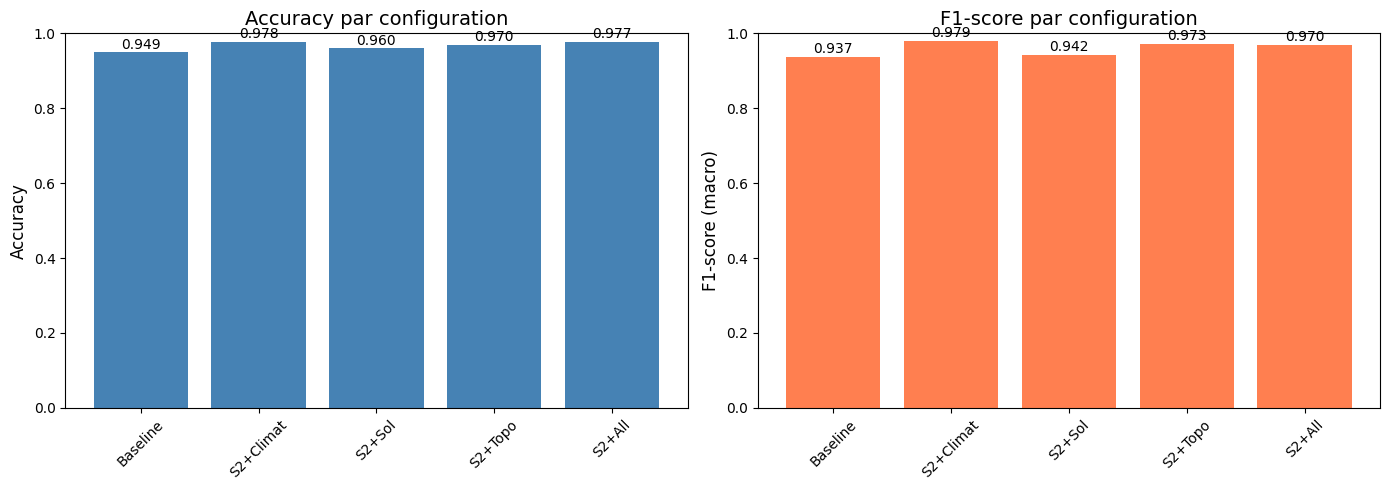

Graphique sauvegarde: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\outputs/ablation_results.png


In [18]:
# CELLULE 15 : Visualisation des résultats

import matplotlib.pyplot as plt

output_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\outputs'
os.makedirs(output_path, exist_ok=True)

# Créer le dictionnaire des résultats à partir des variables
results = {
    'Baseline': {'accuracy': acc1, 'f1': f1_1},
    'S2+Climat': {'accuracy': acc2, 'f1': f1_2},
    'S2+Sol': {'accuracy': acc3, 'f1': f1_3},
    'S2+Topo': {'accuracy': acc4, 'f1': f1_4},
    'S2+All': {'accuracy': acc5, 'f1': f1_5},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = list(results.keys())
accs = [results[c]['accuracy'] for c in configs]
f1s = [results[c]['f1'] for c in configs]

axes[0].bar(configs, accs, color='steelblue')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy par configuration', fontsize=14)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
for bar, acc in zip(axes[0].patches, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.3f}', ha='center', fontsize=10)

axes[1].bar(configs, f1s, color='coral')
axes[1].set_ylabel('F1-score (macro)', fontsize=12)
axes[1].set_title('F1-score par configuration', fontsize=14)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)
for bar, f1 in zip(axes[1].patches, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{f1:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{output_path}/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Graphique sauvegarde: {output_path}/ablation_results.png")

# save results

In [19]:
# CELLULE 16 : Sauvegarde des résultats en CSV

import pandas as pd

results_df = pd.DataFrame([
    {'Configuration': 'Baseline', 'Accuracy': acc1, 'F1_Score': f1_1},
    {'Configuration': 'S2+Climat', 'Accuracy': acc2, 'F1_Score': f1_2},
    {'Configuration': 'S2+Sol', 'Accuracy': acc3, 'F1_Score': f1_3},
    {'Configuration': 'S2+Topo', 'Accuracy': acc4, 'F1_Score': f1_4},
    {'Configuration': 'S2+All', 'Accuracy': acc5, 'F1_Score': f1_5},
])

results_df.to_csv(f'{output_path}/ablation_results.csv', index=False)
print(f"Resultats sauvegardes dans {output_path}/ablation_results.csv")

Resultats sauvegardes dans C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\outputs/ablation_results.csv


# Cellule 16 : Conclusion

In [20]:
# CELLULE 17 : Tableau récapitulatif texte

print("\n" + "=" * 70)
print("TABLEAU RECAPITULATIF - RESULTATS FINAUX")
print("=" * 70)
print(f"{'Configuration':35} | {'Accuracy':10} | {'F1-score':10} | {'Gain Acc':10}")
print("-" * 75)

baseline_acc = acc1

configs_list = [
    ("Baseline", acc1, f1_1),
    ("S2+Climat", acc2, f1_2),
    ("S2+Sol", acc3, f1_3),
    ("S2+Topo", acc4, f1_4),
    ("S2+All", acc5, f1_5),
]

for name, acc, f1 in configs_list:
    gain = acc - baseline_acc
    print(f"{name:35} | {acc:.4f}    | {f1:.4f}    | +{gain:.4f}")

print("\n" + "=" * 70)
print("MEILLEURE CONFIGURATION:")
best_acc = max([acc2, acc3, acc4, acc5])
if best_acc == acc2:
    print("  S2+Climat: Accuracy = {:.4f}, F1 = {:.4f}".format(acc2, f1_2))
elif best_acc == acc3:
    print("  S2+Sol: Accuracy = {:.4f}, F1 = {:.4f}".format(acc3, f1_3))
elif best_acc == acc4:
    print("  S2+Topo: Accuracy = {:.4f}, F1 = {:.4f}".format(acc4, f1_4))
else:
    print("  S2+All: Accuracy = {:.4f}, F1 = {:.4f}".format(acc5, f1_5))
print("=" * 70)


TABLEAU RECAPITULATIF - RESULTATS FINAUX
Configuration                       | Accuracy   | F1-score   | Gain Acc  
---------------------------------------------------------------------------
Baseline                            | 0.9490    | 0.9373    | +0.0000
S2+Climat                           | 0.9781    | 0.9789    | +0.0291
S2+Sol                              | 0.9600    | 0.9415    | +0.0110
S2+Topo                             | 0.9700    | 0.9727    | +0.0210
S2+All                              | 0.9766    | 0.9695    | +0.0276

MEILLEURE CONFIGURATION:
  S2+Climat: Accuracy = 0.9781, F1 = 0.9789


VÉRIFICATION DES DONNÉES DE SOL

1. APERÇU DES DONNÉES SOL:
   soil_ph  soil_oc  soil_texture
0     76.0      2.0           4.0
1     73.0      2.0           4.0
2     74.0      2.0           4.0
3     75.0      2.0           4.0
4     73.0      3.0           4.0
5     73.0      2.0           7.0
6     74.0      2.0           4.0
7     75.0      2.0           4.0
8     72.0      3.0           4.0
9     73.0      2.0           7.0

2. STATISTIQUES PAR COLONNE:

soil_ph:
   Type: float64
   Min: 65.0
   Max: 81.0
   NaN: 12
   Inf: 0
   Valeurs uniques: 17
   Valeurs: [np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(72.0), np.float64(73.0), np.float64(74.0), np.float64(75.0), np.float64(76.0), np.float64(77.0), np.float64(79.0), np.float64(nan), np.float64(78.0), np.float64(80.0), np.float64(81.0)]

soil_oc:
   Type: float64
   Min: 1.0
   Max: 10.0
   NaN: 12
   Inf: 0
   Valeurs uniques: 10
   Vale

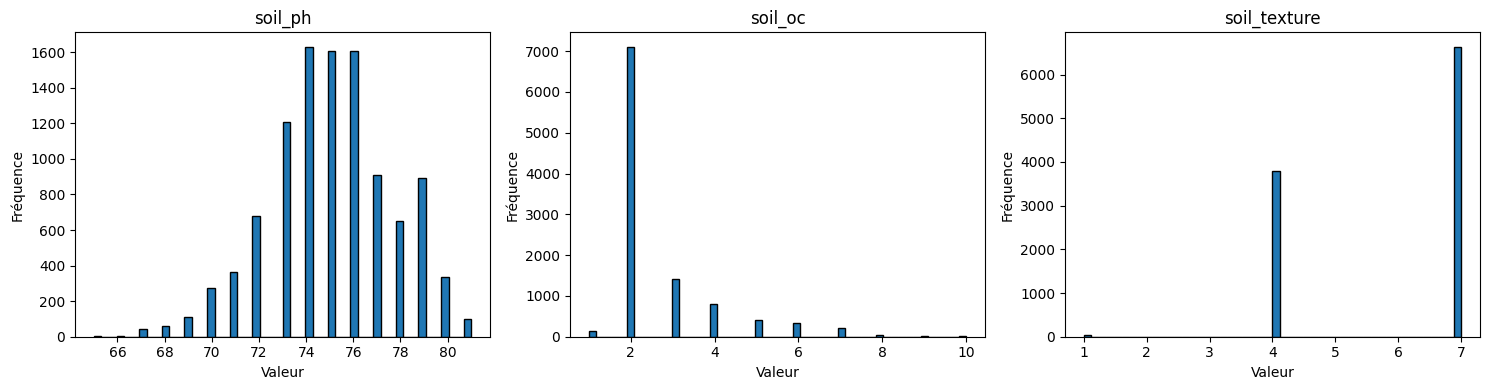

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("VÉRIFICATION DES DONNÉES DE SOL")
print("=" * 60)

# Charger les covariables
cov = pd.read_csv(r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned\covariates.csv')

soil_cols = ['soil_ph', 'soil_oc', 'soil_texture']

print("\n1. APERÇU DES DONNÉES SOL:")
print(cov[soil_cols].head(10))

print("\n2. STATISTIQUES PAR COLONNE:")
for col in soil_cols:
    print(f"\n{col}:")
    print(f"   Type: {cov[col].dtype}")
    print(f"   Min: {cov[col].min()}")
    print(f"   Max: {cov[col].max()}")
    print(f"   NaN: {cov[col].isna().sum()}")
    print(f"   Inf: {np.isinf(cov[col]).sum()}")
    print(f"   Valeurs uniques: {cov[col].nunique()}")
    if cov[col].nunique() < 20:
        print(f"   Valeurs: {sorted(cov[col].unique())}")

print("\n3. VALEURS ABERRANTES (écart-type > 5):")
for col in ['soil_ph', 'soil_oc']:
    mean = cov[col].mean()
    std = cov[col].std()
    outliers = ((cov[col] - mean).abs() > 5 * std).sum()
    print(f"   {col}: {outliers} outliers")

print("\n4. TEST DE NORMALISATION:")
X_test = cov[soil_cols].values
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_test)
print(f"   Avant normalisation - min: {X_test.min():.4f}, max: {X_test.max():.4f}")
print(f"   Après normalisation - min: {X_norm.min():.4f}, max: {X_norm.max():.4f}")
print(f"   Moyenne: {X_norm.mean():.4f}, Écart-type: {X_norm.std():.4f}")

print("\n5. DISTRIBUTION DE soil_texture (variable catégorielle):")
texture_counts = cov['soil_texture'].value_counts().sort_index()
for val, count in texture_counts.items():
    print(f"   {val}: {count} points")

print("\n6. CORRÉLATION ENTRE VARIABLES SOL:")
corr = cov[soil_cols].corr()
print(corr)

# Visualisation rapide
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(soil_cols):
    axes[i].hist(cov[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig('soil_distributions.png')
print("\n Histogrammes sauvegardés dans 'soil_distributions.png'")

print("\n" + "=" * 60)
print("CONCLUSION:")
print("=" * 60)

# Détection des problèmes
problems = []
if cov[soil_cols].isna().sum().sum() > 0:
    problems.append(" Il y a des valeurs NaN")
if (cov[soil_cols] == -999).any().any():
    problems.append(" Il y a des valeurs -999 (souvent des valeurs manquantes)")
if cov['soil_texture'].nunique() < 10:
    problems.append(" soil_texture est catégorielle (peu de valeurs uniques)")
if (cov['soil_ph'] < 3).any() or (cov['soil_ph'] > 11).any():
    problems.append(" Des valeurs pH en dehors de la plage normale (3-11)")

if problems:
    print("\nProblèmes détectés:")
    for p in problems:
        print(f"   {p}")
    print("\n🔧 Correction recommandée:")
    print("   - Remplacer les valeurs manquantes par la médiane")
    print("   - Encoder soil_texture en one-hot (variable catégorielle)")
else:
    print("\n Aucun problème majeur détecté")
    
print("\n Les résultats anormaux (Accuracy=0.38) viennent probablement")
print("   de soil_texture qui est une variable catégorielle. Il faut")
print("   l'encoder en one-hot avant de l'utiliser.")